### Graph의 실행 흐름 중간에 사용자가 직접 개입하는 방법

In [29]:
from typing_extensions import TypedDict
from typing import Annotated
import operator

import sqlite3
from langgraph.checkpoint.sqlite import SqliteSaver

class State(TypedDict):
    messages: Annotated[list[str], operator.add]


In [ ]:
from langgraph.graph import StateGraph, START, END
from langgraph.types import interrupt

def process_task(state: State):
    print("\n=== process_task node 시작 ===")
    print(f"현재 messages: {state['messages']}")

    approval = interrupt("계속 진행할까요? (True/False)")
    print("interrupt 발생! (사용자 승인 대기)")

    print(f"\n사용자가 응답했습니다: {approval}")

    if approval:
        print("승인되었습니다! 작업을 진행합니다.")
        return {"messages": ["작업이 성공적으로 완료되었습니다!"]}
    else:
        print("거부되었습니다. 작업을 취소합니다.")
        return {"messages": ["작업이 취소되었습니다."]}

graph_builder = StateGraph(State)

graph_builder.add_node("process_task", process_task)

graph_builder.add_edge(START, "process_task")
graph_builder.add_edge("process_task", END)

checkpointer = SqliteSaver(sqlite3.connect("./db/checkpoints.db", check_same_thread=False))
graph = graph_builder.compile(checkpointer=checkpointer)

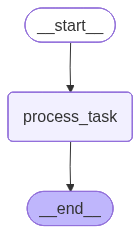

In [31]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

In [32]:
config = {"configurable": {"thread_id": "thread_02"}}
result = graph.invoke({"messages": ["시작"]}, config)


=== process_task node 시작 ===
현재 messages: ['시작', '시작', '시작', '작업이 성공적으로 완료되었습니다!', '시작']


In [33]:
result.get("messages")

['시작', '시작', '시작', '작업이 성공적으로 완료되었습니다!', '시작']

In [34]:
result.get("__interrupt__")

[Interrupt(value='계속 진행할까요? (True/False)', id='a94d5faad76eb70c8ec38db0a9d9d946')]

In [35]:
state = graph.get_state(config)

In [49]:
state

StateSnapshot(values={'messages': ['시작', '시작', '시작', '작업이 성공적으로 완료되었습니다!', '시작']}, next=('process_task',), config={'configurable': {'thread_id': 'thread_02', 'checkpoint_ns': '', 'checkpoint_id': '1f10d2b3-be26-6cb6-8007-c3597692dbd9'}}, metadata={'source': 'loop', 'step': 7, 'parents': {}}, created_at='2026-02-19T00:37:56.464045+00:00', parent_config={'configurable': {'thread_id': 'thread_02', 'checkpoint_ns': '', 'checkpoint_id': '1f10d2b3-be24-6302-8006-ab0550fffc55'}}, tasks=(PregelTask(id='924565f1-e49c-8cf6-6a7b-e2a134e89a3d', name='process_task', path=('__pregel_pull', 'process_task'), error=None, interrupts=(Interrupt(value='계속 진행할까요? (True/False)', id='a94d5faad76eb70c8ec38db0a9d9d946'),), state=None, result=None),), interrupts=(Interrupt(value='계속 진행할까요? (True/False)', id='a94d5faad76eb70c8ec38db0a9d9d946'),))

In [36]:
state.next

('process_task',)

In [37]:
state.values.get('messages', [])

['시작', '시작', '시작', '작업이 성공적으로 완료되었습니다!', '시작']

---

#### 실행 재개

사용자 "승인"하기

In [38]:
state.next

('process_task',)

In [48]:
state.interrupts

(Interrupt(value='계속 진행할까요? (True/False)', id='a94d5faad76eb70c8ec38db0a9d9d946'),)

In [39]:
prompt = state.interrupts[0].value
user_input = input(prompt + " > ") # 재개(resume)를 위해 사용자 입력 받기


In [40]:
from langgraph.types import interrupt, Command

user_bool = user_input.lower() == "true"
result = graph.invoke(Command(resume=user_bool), config)


=== process_task node 시작 ===
현재 messages: ['시작', '시작', '시작', '작업이 성공적으로 완료되었습니다!', '시작']
interrupt 발생! (사용자 승인 대기)

사용자가 응답했습니다: True
승인되었습니다! 작업을 진행합니다.


In [41]:
result['messages']

['시작', '시작', '시작', '작업이 성공적으로 완료되었습니다!', '시작', '작업이 성공적으로 완료되었습니다!']

---

In [42]:
config = {"configurable": {"thread_id": "thread_03"}}
result = graph.invoke({"messages": ["시작"]}, config)


=== process_task node 시작 ===
현재 messages: ['시작', '작업이 취소되었습니다.', '시작']


In [43]:
result.get("messages")

['시작', '작업이 취소되었습니다.', '시작']

In [44]:
result.get("__interrupt__")

[Interrupt(value='계속 진행할까요? (True/False)', id='b44a0d9049f3f7df180ccc1adfa8a6c2')]

In [45]:
prompt = state.interrupts[0].value
user_input = input(prompt + " > ") # 재개(resume)를 위해 사용자 입력 받기

In [46]:
from langgraph.types import interrupt, Command

user_bool = user_input.lower() == "true"
result = graph.invoke(Command(resume=user_bool), config)


=== process_task node 시작 ===
현재 messages: ['시작', '작업이 취소되었습니다.', '시작']
interrupt 발생! (사용자 승인 대기)

사용자가 응답했습니다: False
거부되었습니다. 작업을 취소합니다.
